# Visualization

In [1]:
import contextlib
import pandas as pd
import polars as pl
from tqdm import tqdm

In [22]:
# On simplifie en 8 grands partis d'après https://fr.wikipedia.org/wiki/Liste_des_partis_politiques_en_France_sous_la_Cinqui%C3%A8me_R%C3%A9publique
# On ne code pas tout de suite par un nombre pour pouvoir extraire des sous-graphes
corrections = {
    'non mentionné' : '',
    'indépendant' : '',
    'indépendants' : '',
    'sans étiquette' : '',
    'libre' : '',
    'libres' : '',
    'non inscrits' : '',
    'non inscrit' : '',
    'sans parti politique' : '',
    'hors des partis' : '',
    'abertzale' : '',
    'Fédération nationale des indépendants' : '',
    'Front national' : 'Extrême droite',
    'Rassemblement pour la République' : 'Droite',
    'Union gaulliste pour la démocratie' : 'Droite',
    'Mouvement des gaullistes populaires' : 'Droite',
    'Mouvement solidarité participation' : 'Droite',
    'Parti républicain' : 'Droite',
    'divers droite' : 'Droite',
    'droite' : 'Droite',
    'Centre national des indépendants et paysans' : 'Droite',
    'centre droit' : 'Centre droit', # proche udf en 1988
    'Parti ouvrier européen' : 'Centre droit', # proche udf en 1988
    'Centre des démocrates sociaux' : 'Centre droit',
    'Républicains de progrès' : 'Centre droit',
    'Parti radical' : 'Centre droit',
    'radical' : 'Centre droit',
    'Union pour la démocratie française' : 'Centre droit',
    'Parti radical-socialiste' : 'Centre droit', # pas parti radical de gauche
    'centriste' : 'Centre',
    'centre' : 'Centre',
    'Démocrates de progrès' : 'Centre',
    'centre gauche' : 'Centre gauche',
    'Parti social-démocrate' : 'Centre gauche',
    'Parti démocrate français' : 'Centre gauche',
    'Mouvement des radicaux de gauche' : 'Centre gauche',
    'gauche' : 'Gauche',
    'socialiste' : 'Gauche',
    'socialistes' : 'Gauche',
    'Humaniste' : 'Gauche',
    'Parti humaniste' : 'Gauche',
    'Parti socialiste' : 'Gauche',
    'Parti socialiste unifié' : 'Gauche',
    'Mouvement rouge et vert' : 'Gauche',
    'Comités d\'initiative pour une nouvelle politique à gauche' : 'Gauche',
    'Parti communiste français' : 'Gauche',
    'Parti communiste réunionnais' : 'Gauche',
    'Parti communiste guadeloupéen' : 'Gauche',
    'Verts alternatifs' : 'Verts',
    'Parti vert' : 'Verts',
    'Jura écologie' : 'Verts',
    'vert indépendant' : 'Verts',
    'Mouvement écologique' : 'Verts',
    'Anjou écologie autogestion' : 'Verts',
    'Comités Juquin' : 'Extrême gauche' # LCR
}
# csv1988_exploded['titulaire-soutien'] = csv1988_exploded['titulaire-soutien'].map(corrections)
# print(csv1988_exploded['titulaire-soutien'].value_counts().head(40))

titulaire-soutien
                  1399
Gauche             819
Droite             703
Centre droit       634
Extrême droite     546
Centre gauche       62
Extrême gauche      16
Verts               16
Centre              13
Name: count, dtype: int64


In [2]:
df = pl.read_parquet("df_gliner_full.parquet")

FileNotFoundError: No such file or directory (os error 2): df_gliner_full.parquet

In [23]:
(csv1988_exploded['titulaire-soutien']!='').sum()

np.int64(2903)

In [24]:
# On introduit un index de position
index_position = {
    'Extrême droite' : 1,    'Droite' : 0.8,
    'Centre droit' : 0.6,    'Centre gauche' : 0.4,
    'Gauche' : 0.2, 'Extrême gauche':0, 'Centre':0.5, 'Verts':0.4, '':None
}
csv1988_exploded['titulaire-soutien-position'] = csv1988_exploded['titulaire-soutien'].replace(index_position)

In [25]:
csv1988_exploded['titulaire-soutien-position'].value_counts().head(30)

titulaire-soutien-position
0.2    819
0.8    703
0.6    634
1      546
0.4     78
0       16
0.5     13
Name: count, dtype: int64

In [26]:
temp_aggregation = pd.to_numeric(csv1988_exploded["titulaire-soutien-position"], errors='coerce').groupby(level=0).mean()

In [27]:
temp_aggregation.value_counts().head(30)

titulaire-soutien-position
0.200000    757
1.000000    544
0.700000    377
0.733333    107
0.600000     62
0.800000     47
0.400000     26
0.400000     21
0.300000     16
0.000000     14
0.500000      9
0.666667      6
0.750000      6
0.714286      4
0.466667      4
0.633333      2
0.450000      2
0.266667      2
0.550000      1
0.900000      1
0.133333      1
0.700000      1
0.100000      1
0.657143      1
0.366667      1
0.800000      1
0.250000      1
0.200000      1
Name: count, dtype: int64

In [28]:
df = pd.merge(csv1988, temp_aggregation, how='left', left_index=True, right_index=True)

In [29]:
df

,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,transcript,titulaire-soutien-position
0,EL174_L_1988_06_001_01_1_PF_01,1988-06-05,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1988, Ain - 01, circ...",législatives,1,EL174,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Front national,Liste d'entente populaire et nationale,non,Élections Législatives du 5 Juin 1988 - Départ...,1.0
1,EL174_L_1988_06_001_01_1_PF_02,1988-06-05,Élections législatives;Assemblée Nationale;Ve ...,"Élections législatives de 1988, Ain - 01, circ...",législatives,1,EL174,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Comités Juquin,Une nouvelle politique à gauche,non,RÉPUBLIQUE FRANÇAISE - Liberté - Égalité - Fra...,0.0
2,EL174_L_1988_06_001_01_1_PF_03,1988-06-05,Assemblée Nationale;Ve République;Élections lé...,"Élections législatives de 1988, Ain - 01, circ...",législatives,1,EL174,01,Ain,01 - Ain,...,non mentionné,conseiller général,maire-adjoint honoraire,non mentionné,non mentionné,Rassemblement pour la République;Union pour la...,Union du rassemblement et du centre,oui,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,0.7
3,EL174_L_1988_06_001_01_1_PF_04,1988-06-05,Assemblée Nationale;Ve République;France;Élect...,"Élections législatives de 1988, Ain - 01, circ...",législatives,1,EL174,01,Ain,01 - Ain,...,agriculteur,conseiller général;maire,non mentionné,non mentionné,non mentionné,non mentionné,Bresse unie majorité présidentielle,non,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,NaN
4,EL174_L_1988_06_001_01_1_PF_05,1988-06-05,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Ain - 01, circ...",législatives,1,EL174,01,Ain,01 - Ain,...,employée,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,Rassemblement des forces de gauche,non,RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRA...,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3456,EL177_L_1988_06_974_03_2_PF_02,1988-06-12,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1988, Réunion - 974,...",législatives,2,EL177,974,Réunion,974 - La Réunion,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste réunionnais,Majorité présidentielle,non,Claude HOARAU\nÉgalité Responsabilité Développ...,0.2
3457,EL177_L_1988_06_974_04_2_PF_01,1988-06-12,Ve République;Élections législatives;Assemblée...,"Élections législatives de 1988, Réunion - 974,...",législatives,2,EL177,974,Réunion,974 - La Réunion,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,Sciences Po / fonds CEVIPOF\nAndré Maurice PIH...,NaN
3458,EL177_L_1988_06_974_04_2_PF_02,1988-06-12,Ve République;Élections législatives;France;As...,"Élections législatives de 1988, Réunion - 974,...",législatives,2,EL177,974,Réunion,974 - La Réunion,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste réunionnais,Majorité présidentielle,non,Élie HOARAU\nÉgalité Responsabilité Développem...,0.2
3459,EL177_L_1988_06_974_05_2_PF_01,1988-06-12,France;Ve République;Assemblée Nationale;Élect...,"Élections législatives de 1988, Réunion - 974,...",législatives,2,EL177,974,Réunion,974 - La Réunion,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Union du rassemblement et du centre,non,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,NaN


#Corrections RPR
corrections = {'Union pour la démocratie française;Rassemblement pour la République': 
                    'Rassemblement pour la République;Union pour la démocratie française',
               'Centre national des indépendants et paysans;Rassemblement pour la République;Union pour la démocratie française': 
                    'Rassemblement pour la République;Union pour la démocratie française',
               'Rassemblement pour la République;Union pour la démocratie française;Centre national des indépendants et paysans': 
                    'Rassemblement pour la République;Union pour la démocratie française',
               'Rassemblement pour la République':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Union pour la démocratie française;Rassemblement pour la République;Centre national des indépendants et paysans':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Rassemblement pour la République;Centre national des indépendants et paysans':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Union pour la démocratie française':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Union pour la démocratie française;Centre des démocrates sociaux':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Union pour la démocratie française;Parti républicain':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Centre national des indépendants et paysans;Rassemblement pour la République;Union pour la démocratie française;Mouvement solidarité participation':
                    'Rassemblement pour la République;Union pour la démocratie française',
                'Centre national des indépendants et paysans;Rassemblement pour la République;Union pour la démocratie française;non inscrits':
                    'Rassemblement pour la République;Union pour la démocratie française'}
csv1988['titulaire-soutien'] = csv1988['titulaire-soutien'].replace(corrections)

#Corrections PartiSocialiste
corrections_PS = {'Mouvement des radicaux de gauche;Parti socialiste;Républicains de progrès': 
                    'Parti socialiste',
                'Parti socialiste;Mouvement des radicaux de gauche':
                    'Parti socialiste',
                'socialiste':
                    'Parti socialiste'}
csv1988['titulaire-soutien'] = csv1988['titulaire-soutien'].replace(corrections_PS)

# Autres corrections
corrections_autres = {
    'Parti communiste réunionnais' : 'Parti communiste français',
    'Parti communiste guadeloupéen' : 'Parti communiste français',

    'Verts alternatifs' : 'Verts',
    'Parti vert' : 'Verts',
    
    'indépendant' : 'Indépendants',
    'indépendants' : 'Indépendants',
    'libres;indépendants' : 'Indépendants',
    'libre' : 'Indépendants',
    'hors des partis' : 'Indépendants',
    'sans parti politique' : 'Indépendants',
    'sans étiquette' : 'Indépendants'
}
csv1988['titulaire-soutien'] = csv1988['titulaire-soutien'].replace(corrections_autres)

In [30]:
csv1988.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations',
       'transcript'],
      dtype='str')

# Document embeddings with Word2Vec

In [31]:
# inspired from https://www.geeksforgeeks.org/nlp/doc2vec-in-nlp/

In [32]:
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import spacy
nlp = spacy.load('fr_core_news_sm')

In [33]:
# define a list of documents.
data = ["This is the first document",
        "This is the second document",
        "This is the third document",
        "This is the fourth document"]

def tag_transcript(i:int,s:str):
    w = [str(token) for token in nlp(s.lower())]
    return TaggedDocument(words=w,tags=[str(i)]) 

# preproces the documents, and create TaggedDocuments
tagged_data = [tag_transcript(i,doc) for i,doc in enumerate(data)]
tagged_data

# train the Doc2vec model
model = Doc2Vec(vector_size=20,
                min_count=2, epochs=50)
model.build_vocab(tagged_data)
model.train(tagged_data,
            total_examples=model.corpus_count,
            epochs=model.epochs)

# get the document vectors
document_vectors = [model.infer_vector([str(token) for token in nlp(doc.lower())]) for doc in data]

#  print the document vectors
for i, doc in enumerate(data):
    print("Document", i+1, ":", doc)
    print("Vector:", document_vectors[i])
    print()

Document 1 : This is the first document
Vector: [ 0.01718589  0.00829068  0.01613851  0.00744902 -0.02119646 -0.01986809
  0.01664798 -0.01081923  0.01910906 -0.02451421  0.01756513 -0.00348977
  0.0055663  -0.01366187  0.00940075 -0.00026359  0.00777409  0.01053132
 -0.01732189  0.0168205 ]

Document 2 : This is the second document
Vector: [ 0.01897754  0.01617206  0.00439885  0.00176262  0.02094692  0.02170093
  0.0217893   0.01717964 -0.0221361  -0.01647281  0.00530161 -0.00491605
  0.02205794 -0.0193678   0.02413559 -0.02338314 -0.00984317  0.01763348
  0.0204774  -0.00145711]

Document 3 : This is the third document
Vector: [ 0.00810879 -0.01577646 -0.00230798  0.00395721  0.00424401 -0.01627386
 -0.00512181  0.02412722 -0.020084   -0.01256139 -0.01551158  0.01957348
  0.0157617  -0.01305254 -0.00113463  0.00654919 -0.01593646  0.00280787
  0.01085102 -0.02326258]

Document 4 : This is the fourth document
Vector: [-0.02510148  0.02324577  0.00498922  0.00108181 -0.0060254  -0.0154

In [34]:
df = df.dropna(subset=['transcript']).copy()
df = df.reset_index(drop=True)
def tag_transcript(i:int,s:str):
    w = [str(token) for token in nlp.make_doc(s.lower())]
    return TaggedDocument(words=w,tags=[str(i)]) 

# preproces the documents, and create TaggedDocuments
tagged_data = [tag_transcript(i,doc) for i,doc in tqdm(enumerate(df["transcript"]), desc="Tagging transcripts")]
tagged_data[0:2]

Tagging transcripts: 3461it [00:25, 137.31it/s]


[TaggedDocument(words=['élections', 'législatives', 'du', '5', 'juin', '1988', '-', 'département', 'de', "l'", 'ain', '-', '1re', 'circonscription', '\n', 'sciences', 'po', '/', 'fonds', 'cevipof', '\n', 'maintenant', 'la', 'force', "d'", 'avenir', "c'", 'est', 'le', 'front', 'national', '\n', 'appel', 'aux', 'français', ',', '\n', 'le', '24', 'avril', ',', '4.400.000', 'électrices', 'et', 'électeurs', "m'", 'ont', 'fait', 'confiance', ':', '-', 'pour', 'promouvoir', 'le', 'programme', 'de', 'redressement', 'national', ',', '-', 'pour', 'réduire', 'le', 'chômage', ',', "l'", 'immigration', ',', "l'", 'insécurité', ',', '-', 'pour', 'lutter', 'contre', 'le', 'socialisme', 'bureaucratique', 'et', 'fiscaliste', '.', 'je', 'leur', 'demande', 'de', 'confirmer', 'et', "d'", 'amplifier', 'leur', 'vote', 'le', '5', 'juin', 'prochain', '.', '\n', 'la', 'réélection', 'de', 'françois', 'mitterrand', 'a', 'été', 'rendue', 'possible', 'par', 'les', 'erreurs', 'et', 'les', 'faiblesses', 'du', 'rpr',

In [35]:
# train the Doc2vec model
model = Doc2Vec(vector_size=60,
                min_count=5, epochs=50,
               seed=SEED)
model.build_vocab(tagged_data)
model.train(tagged_data,
            total_examples=model.corpus_count,
            epochs=model.epochs)

In [36]:
# On ajoute les embeddings au dataframe df
df['vector'] = [model.dv[str(i)] for i in range(len(df))]

# Output 1 : travail sur des sous-réseaux

## Output 1 : construction des sous-graphes

In [37]:
df1 = pl.from_pandas(df.copy())
df1 = df1.with_columns(
    pl.col("titulaire-soutien")
        .str.split(";")
        .map_elements(lambda l: l.replace_strict(corrections,default="").unique(), pl.List(pl.String))
        .alias("titulaire-soutien-list")
)

In [38]:
df1.select(pl.col("titulaire-soutien-list")) # list of unique, categorized political parties

titulaire-soutien-list
list[str]
"[""Extrême droite""]"
"[""Extrême gauche""]"
"[""Centre droit"", ""Droite""]"
"[""""]"
"[""Gauche""]"
…
"[""Gauche""]"
"[""""]"
"[""Gauche""]"


In [39]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

In [40]:
# Build one graph

In [41]:
node_list = df1.filter(pl.col("titulaire-soutien-list").list.contains("Centre"))

In [42]:
G = nx.Graph()

In [43]:
similarity_matrix = cosine_similarity(np.array(node_list.get_column("vector").to_list()))
np.fill_diagonal(similarity_matrix,0)
G = nx.from_numpy_array(similarity_matrix) 
weight = G[0][3]['weight']
print(f"Similarity weight: {weight}")

Similarity weight: 0.3653816893839065


In [44]:
node_labels = node_list.with_columns(
    titulaire = pl.concat_str(pl.col("titulaire-nom"),pl.col("titulaire-prenom"),pl.col("contexte-tour"), separator=" ")
).get_column("titulaire").to_list()
label_mapping = {i: name for i, name in enumerate(node_labels)}
G = nx.relabel_nodes(G, label_mapping)

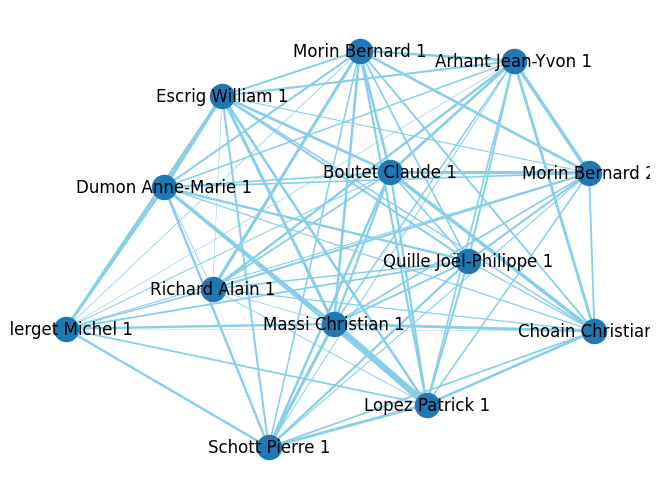

In [45]:
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
nx.draw(G, with_labels=True, width=weights, edge_color="skyblue")

In [46]:
# Build all graphs

In [47]:
def build_one_graph(party_name):
    node_list = df1.filter(pl.col("titulaire-soutien-list").list.contains(party_name))
    G = nx.Graph()
    similarity_matrix = np.maximum(cosine_similarity(np.array(node_list.get_column("vector").to_list())),0) # because cosine similarity can be negative
    np.fill_diagonal(similarity_matrix, 0)
    G = nx.from_numpy_array(similarity_matrix)
    node_labels = node_list.with_columns(
        titulaire = pl.concat_str(pl.col("titulaire-nom"),pl.col("titulaire-prenom"),pl.col("contexte-tour"), separator=" ")
    ).get_column("titulaire").to_list()
    label_mapping = {i: name for i, name in enumerate(node_labels)}
    G = nx.relabel_nodes(G, label_mapping)
    return G

In [48]:
party_list = ['Extrême droite','Droite','Centre droit','Centre',
              'Verts','Centre gauche','Gauche','Extrême gauche']

In [49]:
graph_list = [build_one_graph(name) for name in party_list]

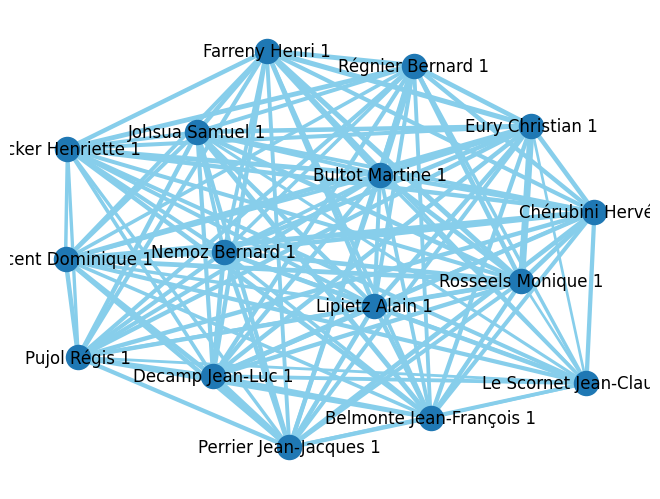

In [50]:
G = graph_list[7]
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
nx.draw(G, with_labels=True, width=weights, edge_color="skyblue")

## Output 1 : paramètres des sous-graphes et visualisation

In [51]:
graph_list

In [52]:
graph_df = pd.DataFrame({'Parti':party_list})

In [53]:
graph_df["number of nodes"] = [len(G.nodes()) for G in graph_list]

In [54]:
G0 = graph_list[7]
temp = [w['weight'] for (i,j,w) in G0.edges(data=True)]
min(temp)

0.3866911788036325

In [55]:
graph_df["min weight"] = [min([d['weight'] for (_,_,d) in G.edges(data=True)]) for G in graph_list]

In [56]:
# graph_df["Average clustering"] = [nx.average_clustering(G, weight='weight') for G in graph_list] # long computation, qq minutes

In [57]:
# graph_df["Average shortest path length"] = [nx.average_shortest_path_length(G, weight='weight') for G in graph_list] # long computation, qq minutes

In [58]:
graph_df

,Parti,number of nodes,min weight
0,Extrême droite,546,0.012553
1,Droite,557,0.000074
2,Centre droit,594,0.000087
3,Centre,13,0.031177
4,Verts,15,0.159269
5,Centre gauche,62,0.004010
6,Gauche,810,0.000018
7,Extrême gauche,16,0.386691


/tmp/ipykernel_24522/3304662679.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45)


[Text(0, 0, 'Extrême droite'),
 Text(1, 0, 'Droite'),
 Text(2, 0, 'Centre droit'),
 Text(3, 0, 'Centre'),
 Text(4, 0, 'Verts'),
 Text(5, 0, 'Centre gauche'),
 Text(6, 0, 'Gauche'),
 Text(7, 0, 'Extrême gauche')]

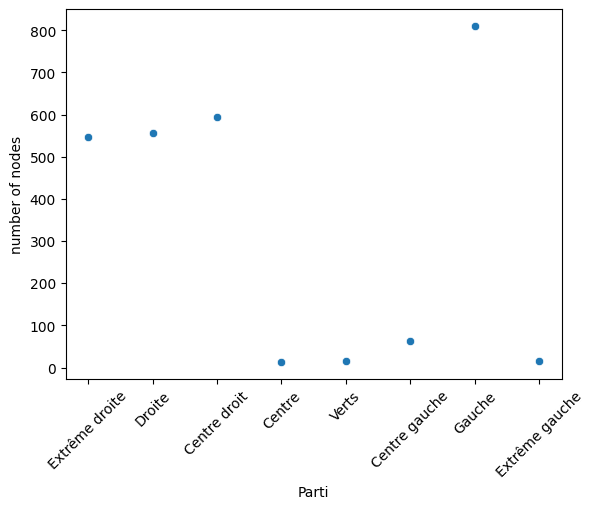

In [59]:
import seaborn as sns
plot = sns.scatterplot(data=graph_df, x="Parti", y="number of nodes")
plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

In [60]:
# plot = sns.scatterplot(data=graph_df, x="Parti", y="Average shortest path length")
# plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

## Output 1 : plutôt avec discrétisation

In [61]:
threshold = 0.3
def build_one_graph(party_name):
    node_list = df1.filter(pl.col("titulaire-soutien-list").list.contains(party_name))
    G = nx.Graph()
    similarity_matrix = cosine_similarity(np.array(node_list.get_column("vector").to_list()))
    np.fill_diagonal(similarity_matrix, 0)
    G = nx.from_numpy_array(np.where(similarity_matrix > threshold, similarity_matrix, 0))
    node_labels = node_list.with_columns(
        titulaire = pl.concat_str(pl.col("titulaire-nom"),pl.col("titulaire-prenom"),pl.col("contexte-tour"), separator=" ")
    ).get_column("titulaire").to_list()
    label_mapping = {i: name for i, name in enumerate(node_labels)}
    G = nx.relabel_nodes(G, label_mapping)
    return G

In [62]:
graph_list = [build_one_graph(name) for name in party_list]

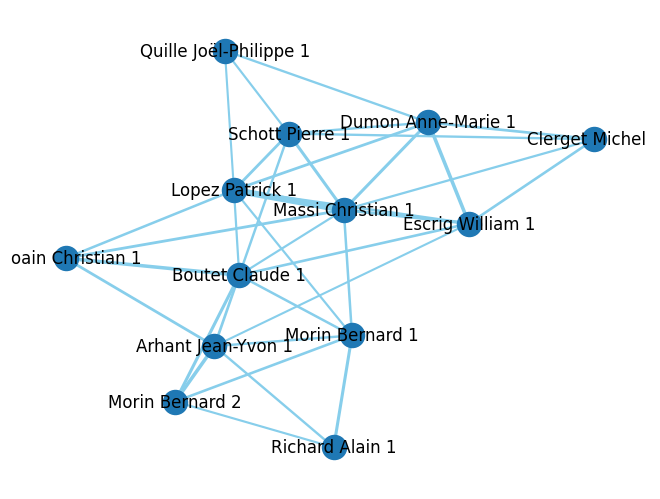

In [63]:
G = graph_list[3]
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
nx.draw(G, with_labels=True, width=weights, edge_color="skyblue")

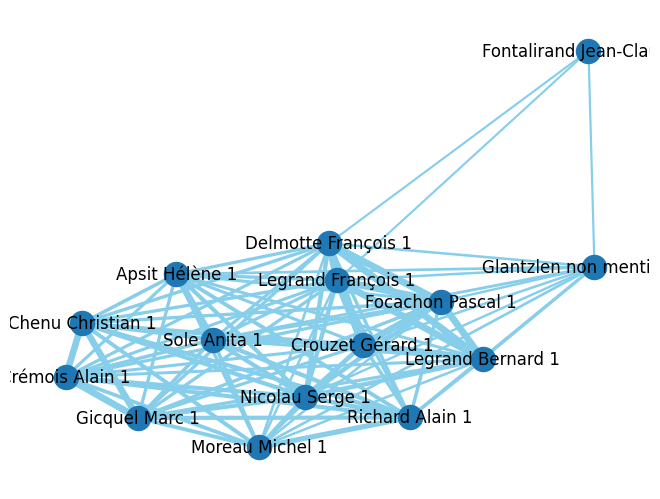

In [64]:
G = graph_list[4]
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
nx.draw(G, with_labels=True, width=weights, edge_color="skyblue")

In [65]:
graph_df = pd.DataFrame({'Parti':party_list})

In [66]:
gg = graph_list[0]
np.mean(list(dict(nx.degree_centrality(gg)).values()))

np.float64(0.9900460395873242)

In [67]:
graph_df["Average degree centrality"] = [np.mean(list(dict(nx.degree_centrality(G)).values())) for G in graph_list]
graph_df["Average shortest path length"] = [nx.average_shortest_path_length(G) for G in graph_list]
graph_df["Average clustering coefficient"] = [nx.average_clustering(G) for G in graph_list]

In [68]:
graph_df

,Parti,Average degree centrality,Average shortest path length,Average clustering coefficient
0,Extrême droite,0.990046,1.009954,0.994974
1,Droite,0.585672,1.414328,0.681412
2,Centre droit,0.591820,1.408180,0.684476
3,Centre,0.461538,1.641026,0.666850
4,Verts,0.866667,1.133333,0.949277
5,Centre gauche,0.692755,1.307245,0.811905
6,Gauche,0.692854,1.307146,0.808501
7,Extrême gauche,1.000000,1.000000,1.000000


/tmp/ipykernel_24522/903406503.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)


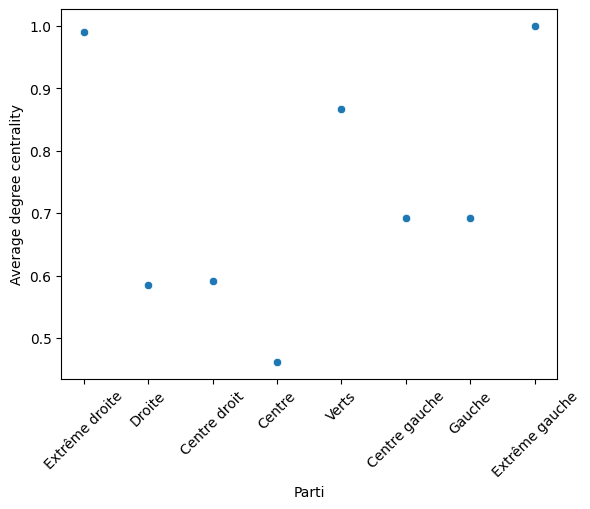

In [69]:
plot = sns.scatterplot(data=graph_df, x="Parti", y="Average degree centrality")
_ = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

/tmp/ipykernel_24522/3431810533.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)


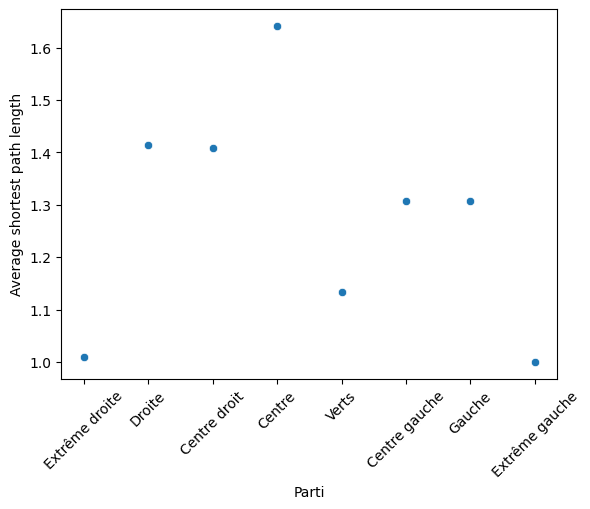

In [70]:
plot = sns.scatterplot(data=graph_df, x="Parti", y="Average shortest path length")
_ = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

/tmp/ipykernel_24522/1946027998.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)


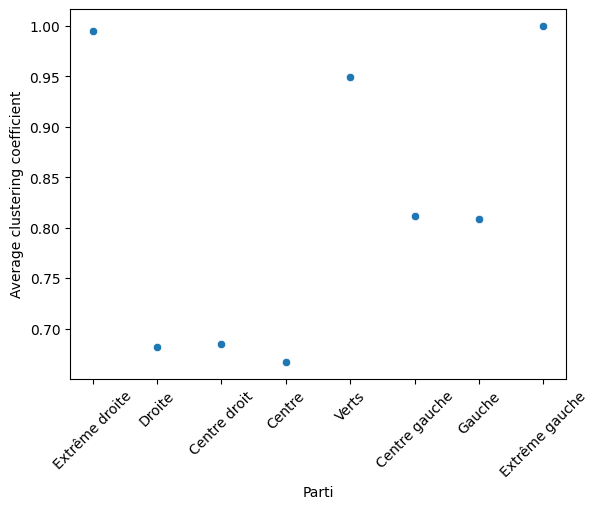

In [71]:
plot = sns.scatterplot(data=graph_df, x="Parti", y="Average clustering coefficient")
_ = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

In [72]:
# Degree distribution
graph_df["degrees"] = [[G.degree(n) for n in G] for G in graph_list]

In [73]:
logBins = np.logspace(np.log10(1), np.log10(1000),num=12)
logBins1 = np.delete(logBins, -1)

def logBinning(degreeList):
    logBinDensity, binedges = np.histogram(degreeList, bins=logBins, density=True)
    return logBinDensity


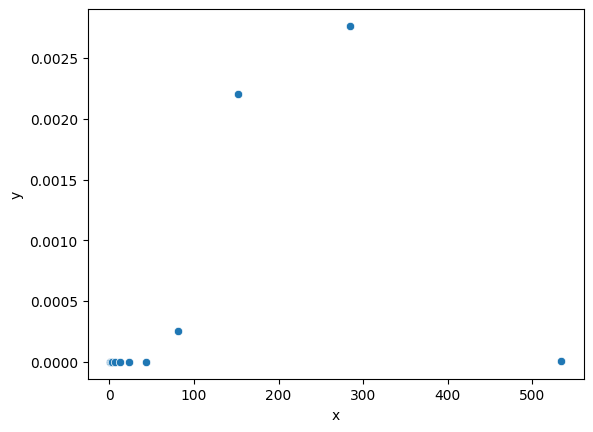

In [74]:
y=logBinning(np.array(graph_df['degrees'][1]))
dff = pd.DataFrame({'x':logBins1, 'y':y})
ax = sns.scatterplot(data=dff, x='x', y='y')
# ax.set(yscale="log", ylim=(0.0001,1))
#ax.set(xscale="log")

[None, (0.0001, 1)]

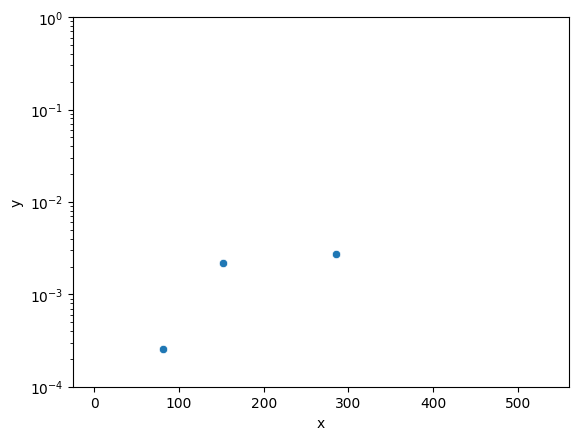

In [75]:
y=logBinning(np.array(graph_df['degrees'][1]))
dff = pd.DataFrame({'x':logBins1, 'y':y})
ax = sns.scatterplot(data=dff, x='x', y='y')
ax.set(yscale="log", ylim=(0.0001,1))
#ax.set(xscale="log")

In [76]:
temp = []
for (G,p) in zip(graph_list,party_list):
    h = list(logBinning(np.array([G.degree(n) for n in G])))
    temp.append( [(x,y,p) for (x,y) in zip(logBins1,h)] )


[None, (1e-05, 1)]

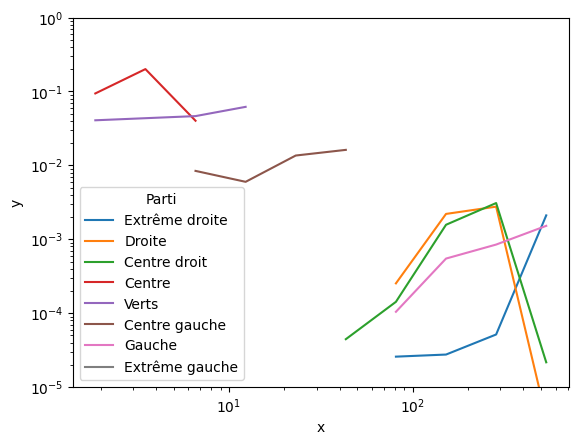

In [77]:
dff = pd.DataFrame(
    sum(temp,[]),
    columns = ['x','y','Parti']
)
dff = dff[dff['y']>0]
ax = sns.lineplot(data=dff, x='x', y='y', hue='Parti')
ax.set(xscale="log")
ax.set(yscale="log", ylim=(0.00001,1))

In [78]:
# on a une power law de façon globale : NON, on ne peut pas "ajouter" des densités
# pour chaque parti : pas de power law, en fait on analyse des communautés, ce n'est pas un réseau global qui pourrait avoir une structure homogène/hétérogène

# Output 2 : Visualisation (préparation du réseau)

In [79]:
import plotly.express as px

In [80]:
import plotly.io as pio
pio.renderers.default = 'iframe'

In [81]:
matrix = np.array(df1["vector"].to_list())
matrix.shape

(3461, 60)

In [82]:
df1 = df1.with_columns(
    pl.col("titulaire-soutien-list")
    .list.get(0)
    .fill_null("")
    .alias("position-politique")
)

In [112]:
tsne = TSNE(
    n_components=2, 
    perplexity=50,
    max_iter=500,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
coords = tsne.fit_transform(matrix)

df1 = df1.with_columns([
    pl.Series(name="x", values=coords[:, 0]),
    pl.Series(name="y", values=coords[:, 1])
])

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 3461 samples in 0.001s...
[t-SNE] Computed neighbors for 3461 samples in 0.098s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3461
[t-SNE] Computed conditional probabilities for sample 2000 / 3461
[t-SNE] Computed conditional probabilities for sample 3000 / 3461


[t-SNE] Computed conditional probabilities for sample 3461 / 3461
[t-SNE] Mean sigma: 1.916796
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.774338
[t-SNE] KL divergence after 500 iterations: 2.380635


In [113]:
df_filtered = df1.filter(pl.col("titulaire-soutien-position").is_not_null())

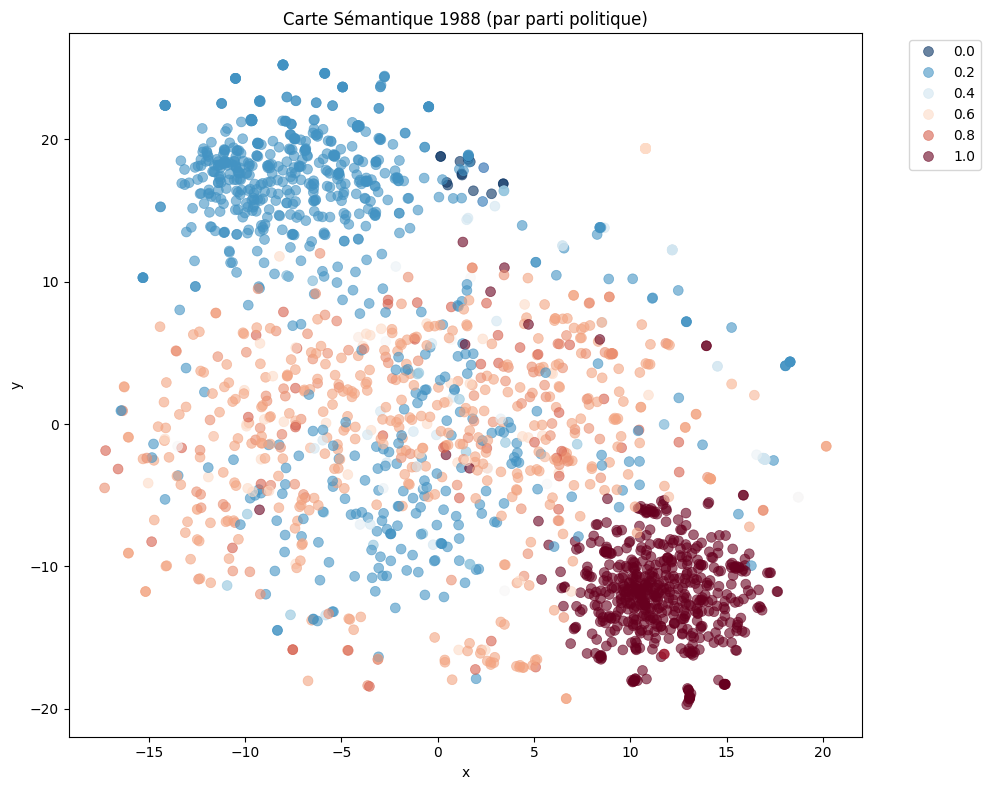

In [117]:
import matplotlib.pyplot as plt
df_pandas = df1.to_pandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pandas,
    x="x",
    y="y",
    hue="titulaire-soutien-position",
    palette="RdBu_r",  # Rouge (droite) à Bleu (gauche)
    alpha=0.6,
    s=50,
    edgecolor=None
)
plt.title("Carte Sémantique 1988 (par parti politique)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()